# Modul 4 — Statistik Inferensial, Korelasi & A/B Testing
## Convergeni Data Consulting (CDC) — Klien: Bank Arta Nusantara

Notebook ini menjalankan seluruh kode inti Modul 4: korelasi skor kredit vs
plafon, A/B test SMS reminder, simulasi Monte Carlo distribusi p-value di
bawah H0, dan simulasi bahaya peeking.

## Data dan Fungsi Inti

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

def hitung_p_value_proporsi(kontrol, treatment):
    x_kontrol, n_kontrol = kontrol.sum(), len(kontrol)
    x_treatment, n_treatment = treatment.sum(), len(treatment)
    count = [x_treatment, x_kontrol]
    nobs = [n_treatment, n_kontrol]
    z_stat, p_value = proportions_ztest(count, nobs, alternative="larger")
    return z_stat, p_value

np.random.seed(42)
n = 300
skor_kredit = np.clip(np.random.normal(65, 12, n), 20, 100)
noise = np.random.normal(0, 60, n)
plafon_pinjaman = np.clip(150 + skor_kredit * 6.2 + noise, 50, None)
df_korelasi = pd.DataFrame({"skor_kredit": skor_kredit, "plafon_pinjaman_juta": plafon_pinjaman})

pearson_r, pearson_p = stats.pearsonr(df_korelasi["skor_kredit"], df_korelasi["plafon_pinjaman_juta"])
print(f"Pearson r = {pearson_r:.4f}, p-value = {pearson_p:.3g}")

n_kontrol = 500
n_treatment = 500
kontrol = np.random.binomial(1, 0.78, n_kontrol)
treatment = np.random.binomial(1, 0.84, n_treatment)
z_stat, p_value = hitung_p_value_proporsi(kontrol, treatment)
print(f"z = {z_stat:.4f}, p-value = {p_value:.4g}")

Pearson r = 0.7728, p-value = 8.42e-61
z = 2.8156, p-value = 0.002434


## Visualisasi 1: Korelasi Skor Kredit vs Plafon (Asset Baru, mengganti M04-03)

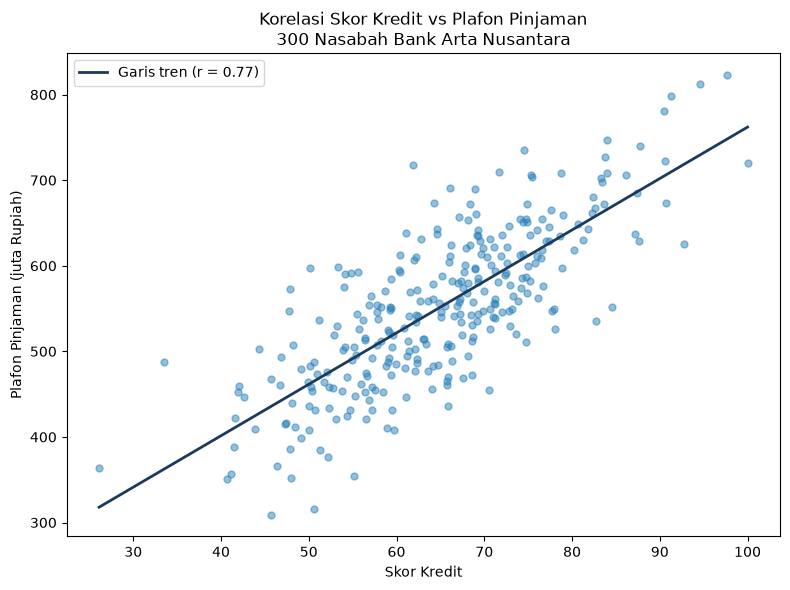

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_korelasi["skor_kredit"], df_korelasi["plafon_pinjaman_juta"], alpha=0.5, color="#2980B9", s=25)

koef = np.polyfit(df_korelasi["skor_kredit"], df_korelasi["plafon_pinjaman_juta"], 1)
x_garis = np.linspace(df_korelasi["skor_kredit"].min(), df_korelasi["skor_kredit"].max(), 100)
ax.plot(x_garis, koef[0] * x_garis + koef[1], color="#1B3A5C", linewidth=2,
        label=f"Garis tren (r = {pearson_r:.2f})")

ax.set_xlabel("Skor Kredit")
ax.set_ylabel("Plafon Pinjaman (juta Rupiah)")
ax.set_title("Korelasi Skor Kredit vs Plafon Pinjaman\n300 Nasabah Bank Arta Nusantara")
ax.legend()
plt.tight_layout()
plt.savefig("modul04_korelasi_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi 2: Distribusi p-value di Bawah H0, Simulasi Monte Carlo (Asset Baru, mengganti M04-01)

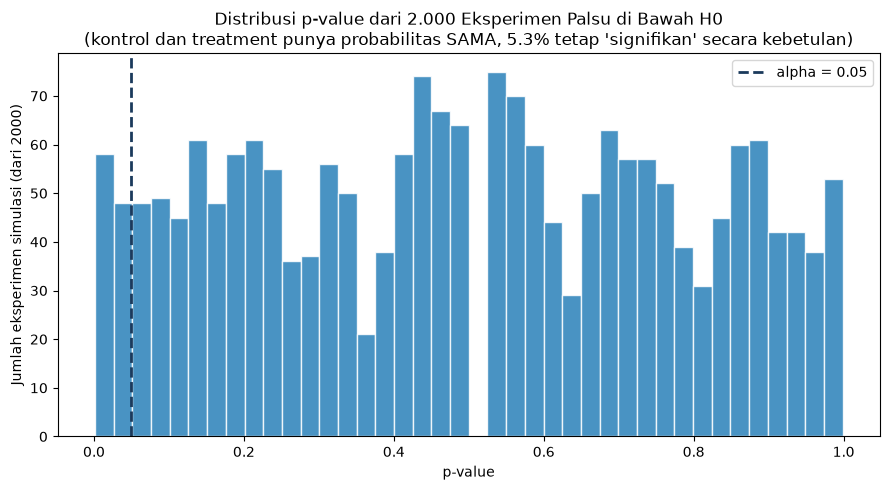

Proporsi p < 0.05 walau H0 benar: 0.0530 (idealnya mendekati 0.05)


In [3]:
# Simulasi 2000 eksperimen A/B PALSU, di mana kontrol dan treatment
# punya probabilitas SAMA PERSIS (H0 benar secara sengaja dibuat benar)
np.random.seed(123)
p_values_h0 = []
for _ in range(2000):
    k = np.random.binomial(1, 0.80, 500)
    t = np.random.binomial(1, 0.80, 500)   # proporsi SAMA seperti kontrol
    _, p = hitung_p_value_proporsi(k, t)
    p_values_h0.append(p)

p_values_h0 = np.array(p_values_h0)
proporsi_di_bawah_005 = (p_values_h0 < 0.05).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(p_values_h0, bins=40, color="#2980B9", edgecolor="white", alpha=0.85)
ax.axvline(0.05, color="#1B3A5C", linestyle="--", linewidth=2, label="alpha = 0.05")
ax.set_xlabel("p-value")
ax.set_ylabel("Jumlah eksperimen simulasi (dari 2000)")
ax.set_title(f"Distribusi p-value dari 2.000 Eksperimen Palsu di Bawah H0\n"
             f"(kontrol dan treatment punya probabilitas SAMA, {proporsi_di_bawah_005*100:.1f}% tetap 'signifikan' secara kebetulan)")
ax.legend()
plt.tight_layout()
plt.savefig("modul04_pvalue_distribusi_h0.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Proporsi p < 0.05 walau H0 benar: {proporsi_di_bawah_005:.4f} (idealnya mendekati 0.05)")

## Visualisasi 3: Bahaya Peeking (Asset Baru, mengganti M04-02)

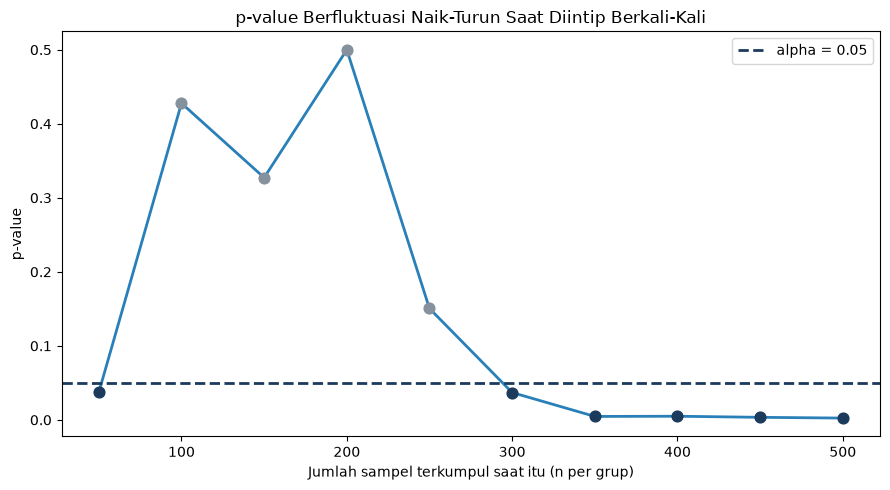

n=  50  p=0.0372  SIGNIFIKAN
n= 100  p=0.4278  -
n= 150  p=0.3272  -
n= 200  p=0.5000  -
n= 250  p=0.1505  -
n= 300  p=0.0369  SIGNIFIKAN
n= 350  p=0.0046  SIGNIFIKAN
n= 400  p=0.0049  SIGNIFIKAN
n= 450  p=0.0035  SIGNIFIKAN
n= 500  p=0.0024  SIGNIFIKAN


In [4]:
# Memakai ULANG variabel kontrol/treatment yang sama dari sel A/B testing di atas
# (kernel yang sama, tidak digambar ulang, supaya angkanya identik dengan bagian sebelumnya)
titik_cek = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
p_values_peek = []
for cp in titik_cek:
    _, p = hitung_p_value_proporsi(kontrol[:cp], treatment[:cp])
    p_values_peek.append(p)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(titik_cek, p_values_peek, marker="o", color="#2980B9", linewidth=2)
ax.axhline(0.05, color="#1B3A5C", linestyle="--", linewidth=2, label="alpha = 0.05")
for x, y in zip(titik_cek, p_values_peek):
    warna_titik = "#1B3A5C" if y < 0.05 else "#85929E"
    ax.scatter([x], [y], color=warna_titik, s=60, zorder=5)
ax.set_xlabel("Jumlah sampel terkumpul saat itu (n per grup)")
ax.set_ylabel("p-value")
ax.set_title("p-value Berfluktuasi Naik-Turun Saat Diintip Berkali-Kali")
ax.legend()
plt.tight_layout()
plt.savefig("modul04_peeking.png", dpi=150, bbox_inches="tight")
plt.show()
for cp, p in zip(titik_cek, p_values_peek):
    print(f"n={cp:>4}  p={p:.4f}  {'SIGNIFIKAN' if p < 0.05 else '-'}")